# VacuumAgent_A01286400 — Intelligent Vacuum Agent

## Objective
Model and implement an intelligent cleaning agent in a dynamic environment using a library alternative to AgentPy.

## Part 1 — Formal Modeling

**Agent model**
- Internal state: position $(x, y)$, cleaned-cells counter.
- Perception: knows all dirty cells (list of coordinates).
- Actions: clean current cell, move 1 step (up/down/left/right), or move randomly if there is no dirt.
- Policy: move toward the nearest dirty cell (bonus heuristic).

**Environment model**
- Representation: $N \times N$ grid with 0 = clean, 1 = dirty.
- Dirt generation: every $n$ steps a random cell becomes dirty.
- Nature: stochastic (due to random dirt generation).

**State transition function**
- Each step: the agent observes → decides movement → cleans if dirty.
- Then the environment may dirty a random cell if scheduled.
- Global state changes by agent movement and grid updates.

**Data structures**
- `grid_state`: matrix/array with clean/dirty state.
- `dirt_positions`: set of dirty coordinates.
- `agent_pos_history`: list of agent positions over time.

In [28]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mesa import Agent, Model
from mesa.space import MultiGrid

In [29]:
class VacuumAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.cleaned = 0

    def step(self):
        # If current cell is dirty, clean it
        if self.pos in self.model.dirt_positions:
            self.model.dirt_positions.remove(self.pos)
            self.model.grid_state[self.pos[0]][self.pos[1]] = 0
            self.cleaned += 1
            self.model.total_cleaned += 1
            return

        # If there is dirt, move toward the nearest dirty cell (heuristic)
        if self.model.dirt_positions:
            target = min(self.model.dirt_positions, key=lambda d: abs(d[0]-self.pos[0]) + abs(d[1]-self.pos[1]))
            dx = np.sign(target[0] - self.pos[0])
            dy = np.sign(target[1] - self.pos[1])
            new_pos = (self.pos[0] + dx, self.pos[1] + dy)
        else:
            # If there is no dirt, move randomly
            x, y = self.pos
            moves = [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]
            moves = [(i,j) for i,j in moves if 0 <= i < self.model.N and 0 <= j < self.model.N]
            new_pos = random.choice(moves)

        self.model.grid.move_agent(self, new_pos)
        self.model.agent_pos_history.append(new_pos)


class VacuumModel(Model):
    def __init__(self, N=10, dirt_interval=5, initial_dirt=10):
        super().__init__()
        self.N = N
        self.dirt_interval = dirt_interval
        self.grid = MultiGrid(N, N, torus=False)
        self.grid_state = np.zeros((N, N), dtype=int)
        self.dirt_positions = set()
        self.total_cleaned = 0
        self.step_count = 0
        self.agent_pos_history = []
        self.agent_list = []

        # Create agent
        self.agent = VacuumAgent(self)
        self.agent_list.append(self.agent)
        self.grid.place_agent(self.agent, (0, 0))
        self.agent_pos_history.append((0, 0))

        # Seed initial dirty cells
        for _ in range(initial_dirt):
            self.add_random_dirt()

    def add_random_dirt(self):
        x, y = random.randrange(self.N), random.randrange(self.N)
        self.grid_state[x][y] = 1
        self.dirt_positions.add((x, y))

    def step(self):
        for agent in self.agent_list:
            agent.step()

        self.step_count += 1

        # Every n steps, dirty a random cell
        if self.step_count % self.dirt_interval == 0:
            self.add_random_dirt()

In [30]:
# Run simulation
N = 10
steps = 100
model = VacuumModel(N=N, dirt_interval=5, initial_dirt=10)

for _ in range(steps):
    model.step()

print("Simulation finished")
print(f"Cleaned cells: {model.total_cleaned}")
print(f"Remaining dirty cells: {len(model.dirt_positions)}")
print(f"Agent final position: {model.agent.pos}")

Simulation finished
Cleaned cells: 28
Remaining dirty cells: 2
Agent final position: (np.int64(7), np.int64(5))


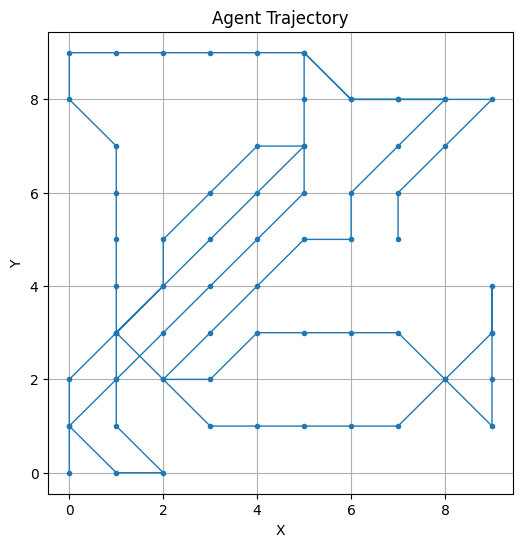

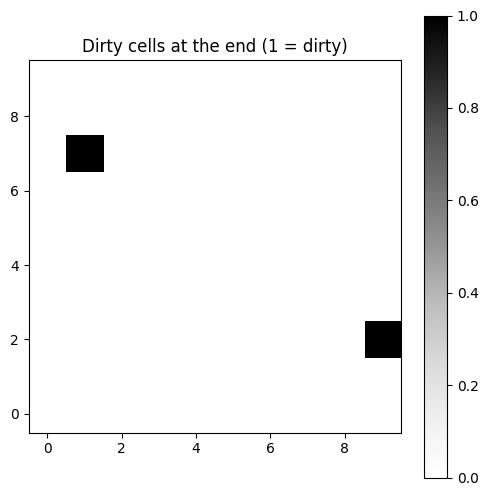

In [31]:
# Simple visualization of agent trajectory
x_coords = [p[0] for p in model.agent_pos_history]
y_coords = [p[1] for p in model.agent_pos_history]

plt.figure(figsize=(6, 6))
plt.plot(x_coords, y_coords, marker='o', markersize=3, linewidth=1)
plt.title('Agent Trajectory')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

# Final grid state
plt.figure(figsize=(6, 6))
plt.imshow(model.grid_state, cmap='Greys', origin='lower')
plt.title('Dirty cells at the end (1 = dirty)')
plt.colorbar()
plt.show()

## Part 3 — Comparative Analysis

**Library Used:** Mesa (Multi-Agent Evolutionary Systems)

**Advantages compared to AgentPy:**
- Greater control over the simulation each step is explicitly defined
- Simpler integration with basic Python objects (Agent, Model, MultiGrid)
- Easy scalability to multiple agents without complex schedulers
- Spatial grid support built-in and well-documented

**Limitations:**
- Fewer visualization tools included by default
- Smaller community and fewer tutorials compared to AgentPy
- Less automatic state tracking

**Scalability:** Mesa is suitable for medium to large systems due to modular architecture and efficient spatial indexing with MultiGrid.

**Preference for Large-Scale Systems:** Mesa is preferred because it offers:
- Fine-grained control over agent behavior and environment dynamics
- Flexibility in designing domain-specific rules
- Better performance with thousands of agents

**Ease of Modeling:** Intermediate—requires more boilerplate than AgentPy but is very explicit and transparent about what happens at each step.

**Visualization:** Basic by default, but integrates well with external visualization libraries.

**Documentation:** Clear and well-structured, though less tutorial-focused than AgentPy.

**Logic Control:** High level of control—each model step can be customized completely.

**Conclusion:** Mesa is ideal when precision, control, and scalability are required. It trades some simplicity for transparency and flexibility, making it well-suited for research and custom multi-agent simulations.